In [2]:
# Import Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.family']    = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

df = pd.read_csv('online_retail_II.csv', encoding='latin1')

print(" Loaded Successfully")
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head()

 Loaded Successfully
Shape   : (1067371, 8)
Columns : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Data Cleaning

print(f"Before cleaning : {len(df):,} rows")

# Parse datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Drop rows with missing Customer ID (can't do customer analysis without it)
df.dropna(subset=['Customer ID'], inplace=True)
df['Customer ID'] = df['Customer ID'].astype(int)

# Drop returns (negative quantity) and zero/negative price
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Drop missing descriptions
df.dropna(subset=['Description'], inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Engineer core features
df['Revenue']      = df['Quantity'] * df['Price']   # line-level revenue
df['Year']         = df['InvoiceDate'].dt.year
df['Month']        = df['InvoiceDate'].dt.month
df['DayOfWeek']    = df['InvoiceDate'].dt.dayofweek
df['Hour']         = df['InvoiceDate'].dt.hour

print(f"After cleaning  : {len(df):,} rows")
print(f"Nulls left      : {df.isnull().sum().sum()}")
print(f"Date Range      : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Unique Customers: {df['Customer ID'].nunique():,}")
df[['Invoice','Quantity','Price','Revenue','Year','Month','Hour']].head(3)

Before cleaning : 1,067,371 rows
After cleaning  : 779,425 rows
Nulls left      : 0
Date Range      : 2009-12-01 → 2011-12-09
Unique Customers: 5,878


,Invoice,Quantity,Price,Revenue,Year,Month,Hour
0,489434,12,6.95,83.4,2009,12,7
1,489434,12,6.75,81.0,2009,12,7
2,489434,12,6.75,81.0,2009,12,7


In [4]:
# Feature Engineering

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Customer-level aggregation
cust = df.groupby('Customer ID').agg(
    Recency          = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    Frequency        = ('Invoice',      'nunique'),
    Monetary         = ('Revenue',      'sum'),
    Avg_Order_Value  = ('Revenue',      'mean'),
    Avg_Price        = ('Price',        'mean'),
    Avg_Quantity     = ('Quantity',     'mean'),
    Total_Items      = ('Quantity',     'sum'),
    Unique_Products  = ('StockCode',    'nunique'),
    Unique_Countries = ('Country',      'nunique'),
    Avg_Hour         = ('Hour',         'mean'),
    Avg_DayOfWeek    = ('DayOfWeek',    'mean'),
).reset_index()

# Derived ratios
cust['Revenue_Per_Item']    = cust['Monetary']    / cust['Total_Items'].replace(0, np.nan)
cust['Products_Per_Order']  = cust['Unique_Products'] / cust['Frequency'].replace(0, np.nan)
cust['Spend_Per_Visit']     = cust['Monetary']    / cust['Frequency'].replace(0, np.nan)

print(" Feature Engineering Done")
print(f"Customer records : {len(cust):,}")
print(f"\nNumeric columns available for correlation:")
num_cols = cust.select_dtypes(include=np.number).columns.drop('Customer ID').tolist()
print(num_cols)
cust.head(3)

 Feature Engineering Done
Customer records : 5,878

Numeric columns available for correlation:
['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Avg_Price', 'Avg_Quantity', 'Total_Items', 'Unique_Products', 'Unique_Countries', 'Avg_Hour', 'Avg_DayOfWeek', 'Revenue_Per_Item', 'Products_Per_Order', 'Spend_Per_Visit']


,Customer ID,Recency,Frequency,Monetary,Avg_Order_Value,Avg_Price,Avg_Quantity,Total_Items,Unique_Products,Unique_Countries,Avg_Hour,Avg_DayOfWeek,Revenue_Per_Item,Products_Per_Order,Spend_Per_Visit
0,12346,326,12,77556.46,2281.072353,6.100000,2184.852941,74285,27,1,12.235294,0.617647,1.044039,2.25,6463.038333
1,12347,2,8,4921.53,22.169054,2.498063,13.364865,2967,126,1,12.518018,2.247748,1.658756,15.75,615.191250
2,12348,75,5,2019.40,39.596078,3.786275,53.215686,2714,25,1,14.745098,1.568627,0.744068,5.00,403.880000


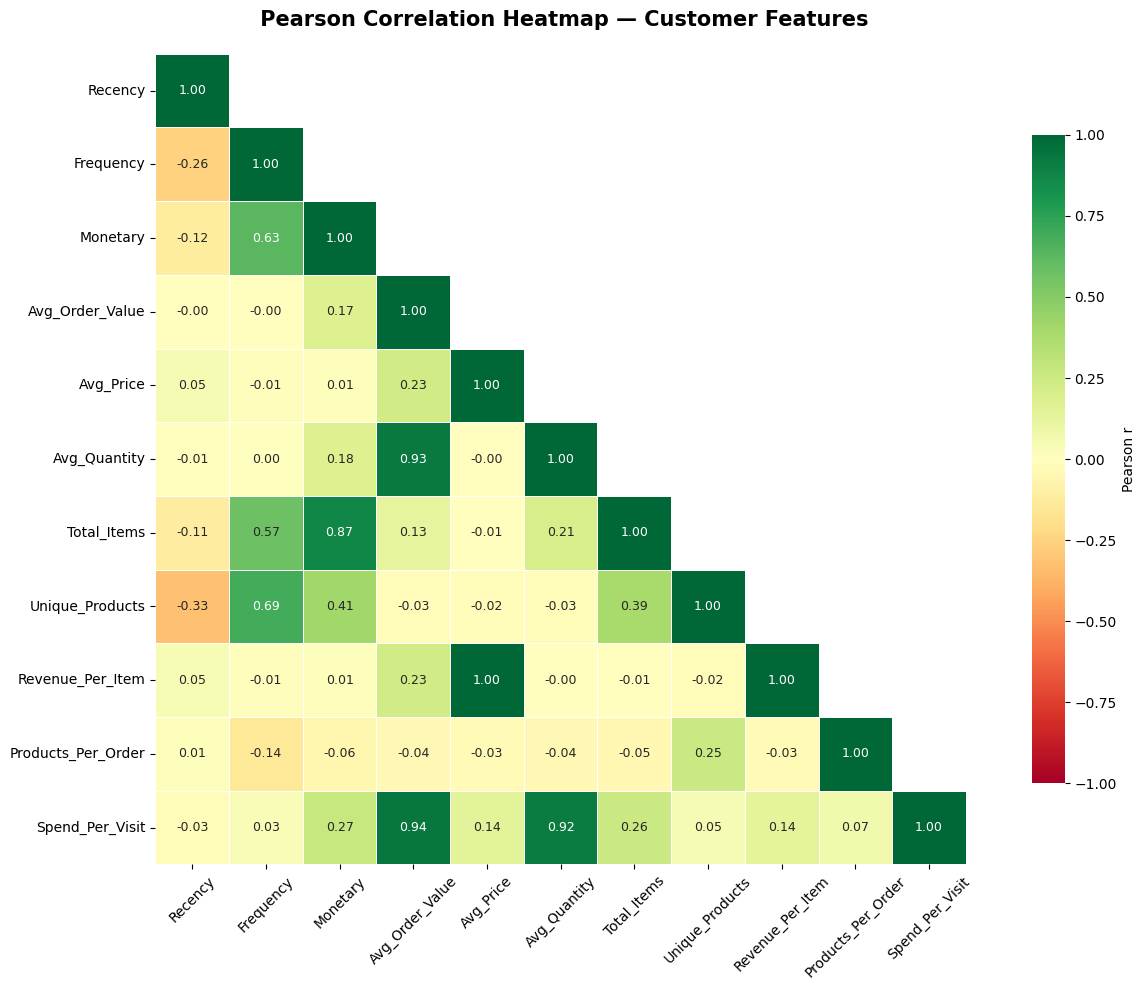

In [5]:
# Pearson Correlation Heatmap

# Select numeric features (drop ID)
num_cols = ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value',
            'Avg_Price', 'Avg_Quantity', 'Total_Items', 'Unique_Products',
            'Revenue_Per_Item', 'Products_Per_Order', 'Spend_Per_Visit']

corr_matrix = cust[num_cols].corr(method='pearson')

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9},
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)

ax.set_title(' Pearson Correlation Heatmap — Customer Features',
             fontsize=15, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=10)

plt.tight_layout()
plt.show()

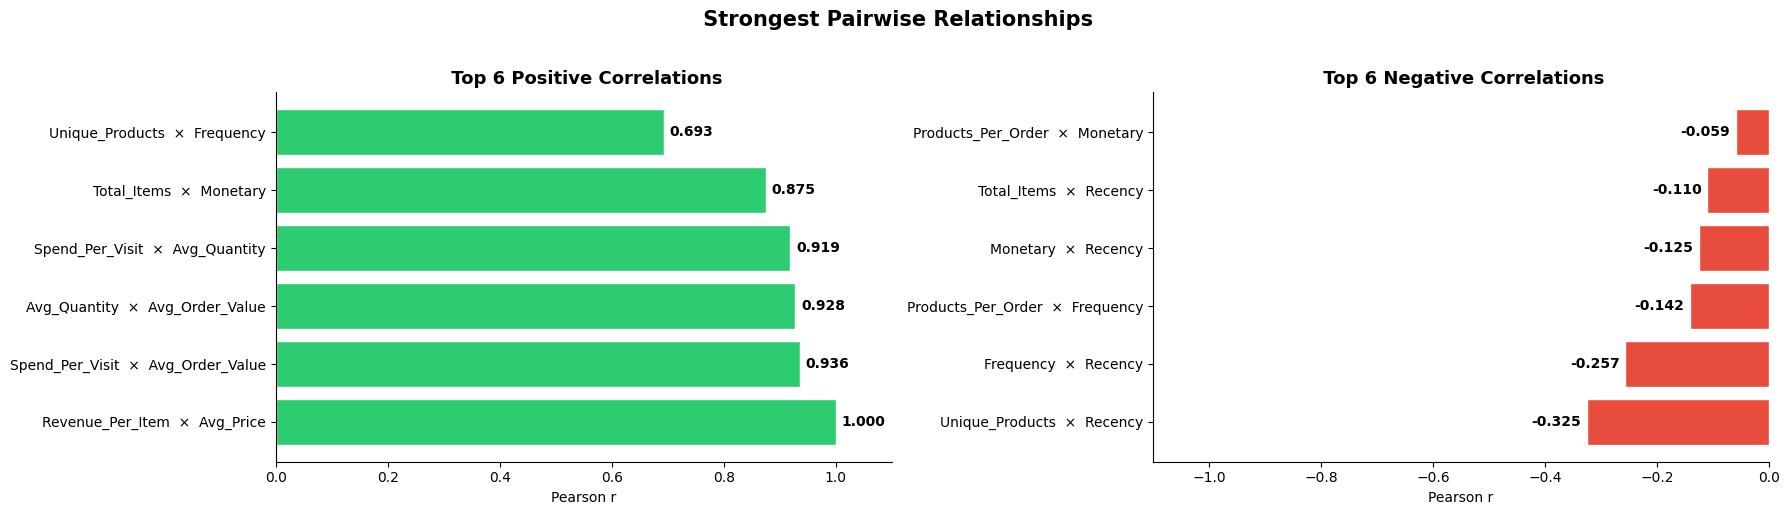


 TOP POSITIVE:
       Feature_A       Feature_B  Pearson_r
Revenue_Per_Item       Avg_Price   0.999539
 Spend_Per_Visit Avg_Order_Value   0.935802
    Avg_Quantity Avg_Order_Value   0.927719
 Spend_Per_Visit    Avg_Quantity   0.918919
     Total_Items        Monetary   0.874546
 Unique_Products       Frequency   0.693113

 TOP NEGATIVE:
         Feature_A Feature_B  Pearson_r
   Unique_Products   Recency  -0.325477
         Frequency   Recency  -0.257013
Products_Per_Order Frequency  -0.141523
          Monetary   Recency  -0.124956
       Total_Items   Recency  -0.110038
Products_Per_Order  Monetary  -0.059323


In [6]:
# Strongest Correlations Summary

# Extract unique pairs (lower triangle only)
corr_pairs = (corr_matrix
              .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
              .stack()
              .reset_index())
corr_pairs.columns = ['Feature_A', 'Feature_B', 'Pearson_r']
corr_pairs['Abs_r'] = corr_pairs['Pearson_r'].abs()
corr_pairs = corr_pairs.sort_values('Pearson_r', ascending=False)

top_pos = corr_pairs.head(6)
top_neg = corr_pairs.tail(6).sort_values('Pearson_r')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── Top Positive
bars = axes[0].barh(
    top_pos['Feature_A'] + '  ×  ' + top_pos['Feature_B'],
    top_pos['Pearson_r'],
    color='#2ecc71', edgecolor='white'
)
axes[0].set_title(' Top 6 Positive Correlations', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pearson r')
axes[0].set_xlim(0, 1.1)
for bar, val in zip(bars, top_pos['Pearson_r']):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

# ── Top Negative
bars2 = axes[1].barh(
    top_neg['Feature_A'] + '  ×  ' + top_neg['Feature_B'],
    top_neg['Pearson_r'],
    color='#e74c3c', edgecolor='white'
)
axes[1].set_title(' Top 6 Negative Correlations', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pearson r')
axes[1].set_xlim(-1.1, 0)
for bar, val in zip(bars2, top_neg['Pearson_r']):
    axes[1].text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='right', fontsize=10, fontweight='bold')

plt.suptitle(' Strongest Pairwise Relationships', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n TOP POSITIVE:")
print(top_pos[['Feature_A','Feature_B','Pearson_r']].to_string(index=False))
print("\n TOP NEGATIVE:")
print(top_neg[['Feature_A','Feature_B','Pearson_r']].to_string(index=False))

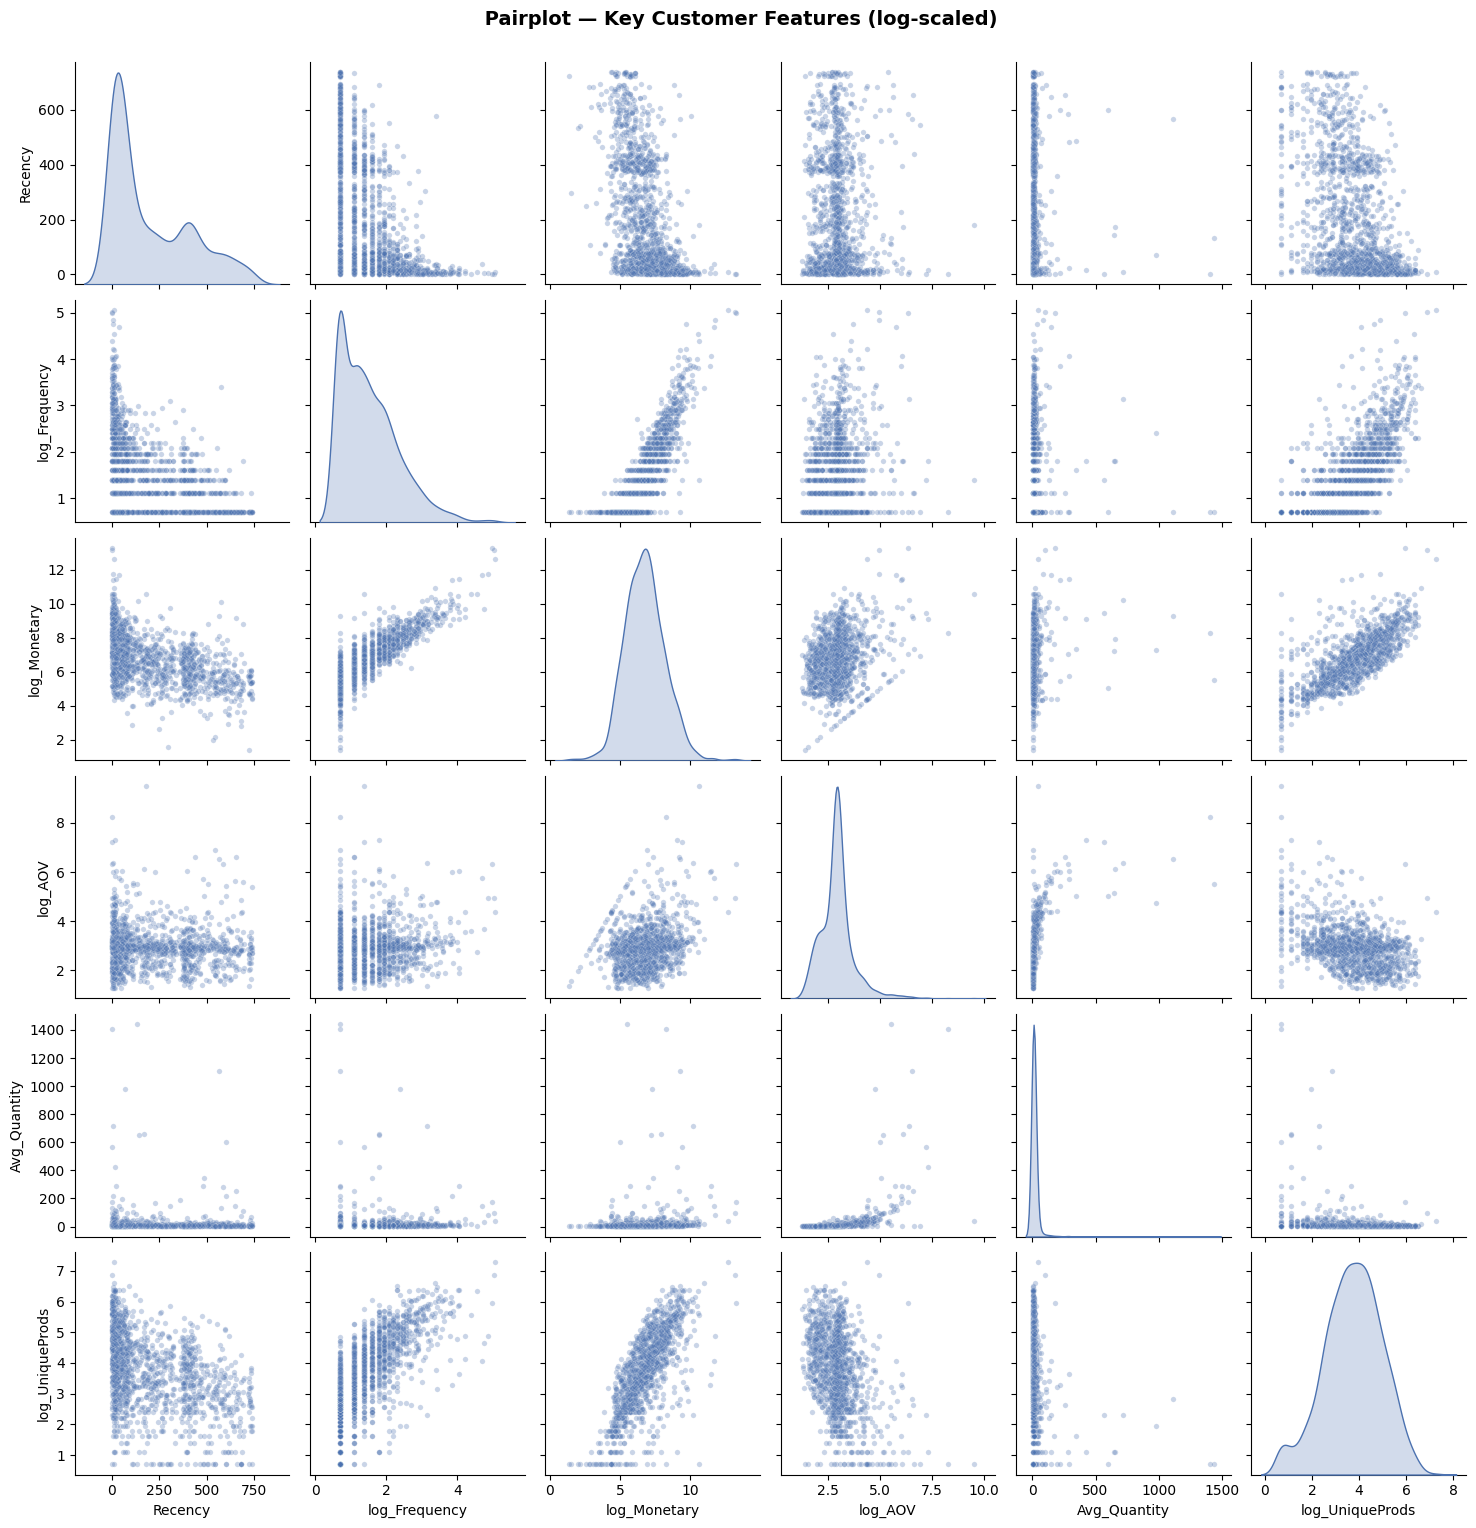

In [7]:
# Pairplot — Key Variables

# Use a sample for speed (pairplot is slow on 5000+ rows)
sample = cust[['Recency','Frequency','Monetary',
               'Avg_Order_Value','Avg_Quantity','Unique_Products']].sample(
               n=min(1500, len(cust)), random_state=42)

# Log-transform skewed columns for better visibility
for col in ['Monetary','Frequency','Avg_Order_Value','Unique_Products']:
    sample[col] = np.log1p(sample[col])

sample.columns = ['Recency', 'log_Frequency', 'log_Monetary',
                  'log_AOV', 'Avg_Quantity', 'log_UniqueProds']

g = sns.pairplot(
    sample,
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15, 'color': '#4C72B0'},
    diag_kws={'color': '#4C72B0', 'fill': True}
)
g.figure.suptitle(' Pairplot — Key Customer Features (log-scaled)',
                  fontsize=14, fontweight='bold', y=1.02)
plt.show()

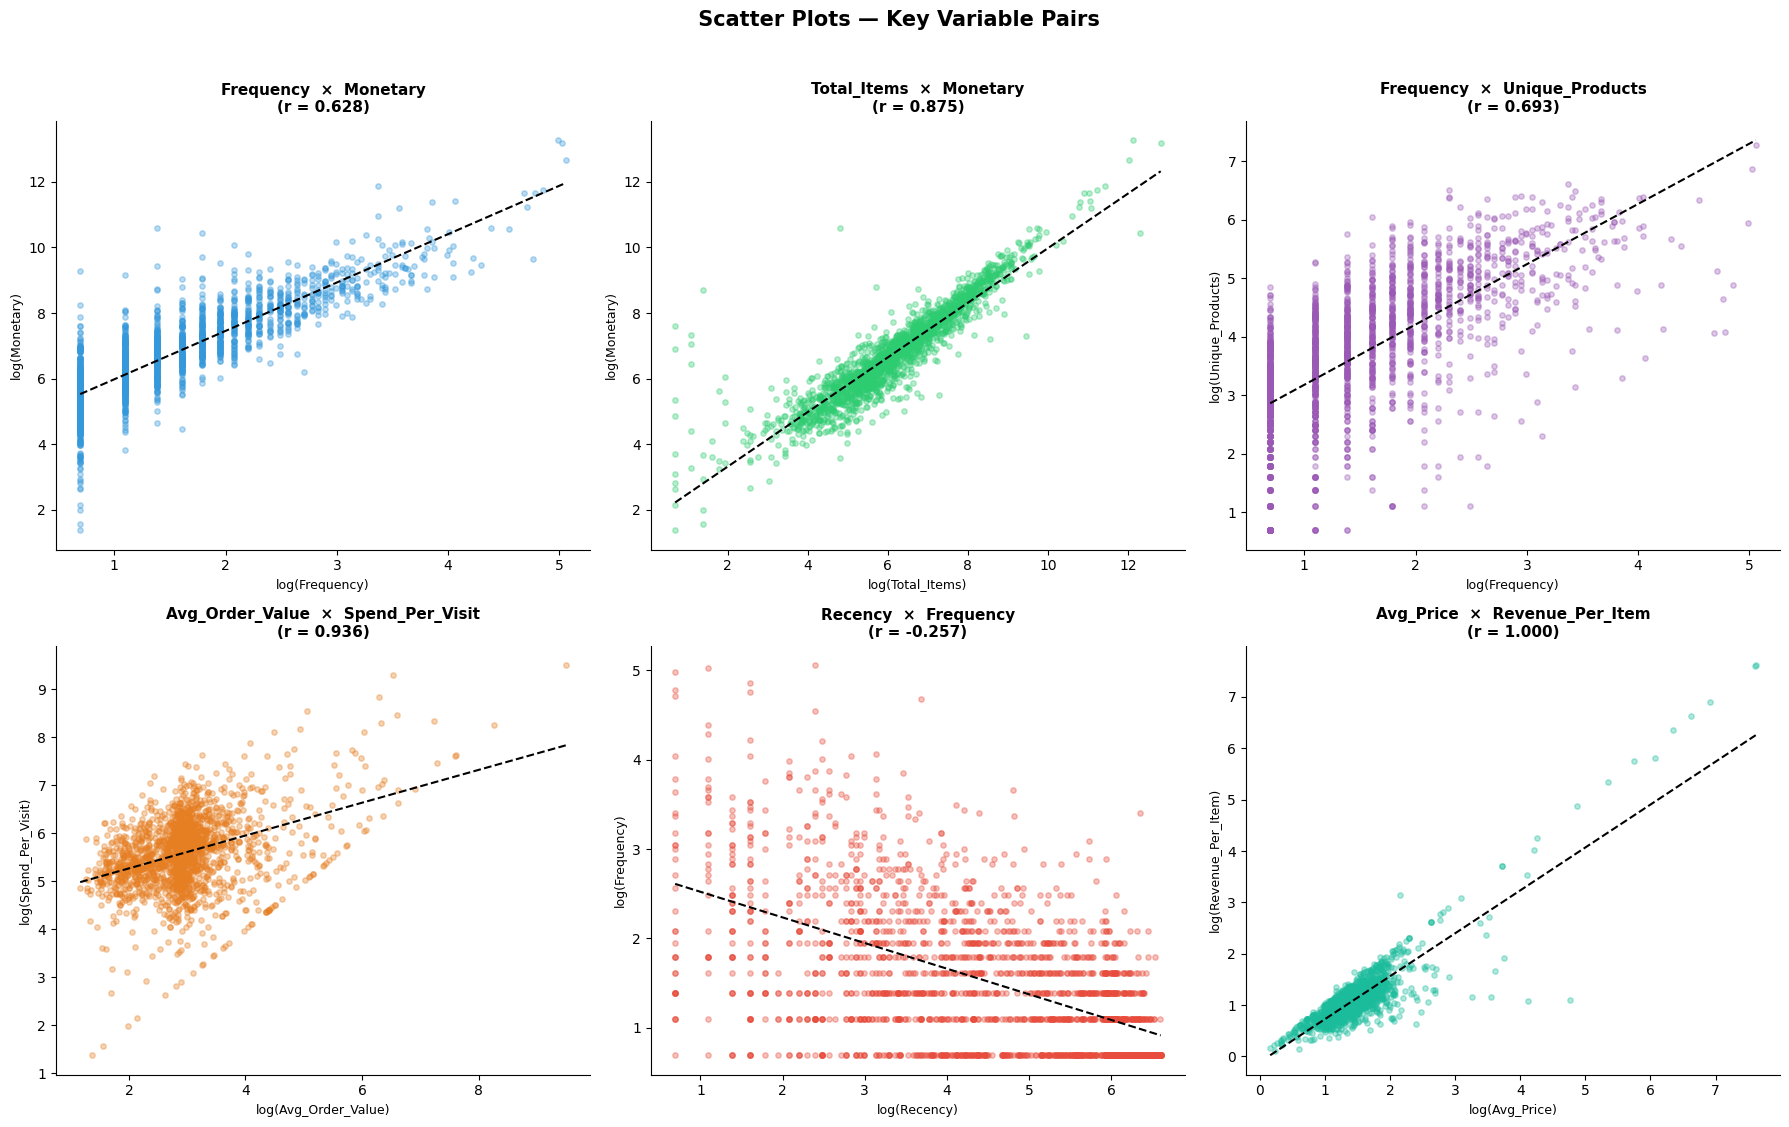

In [8]:
# Scatter Plots — Top Correlated Pairs

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

pairs = [
    ('Frequency',       'Monetary',         '#3498db'),
    ('Total_Items',     'Monetary',         '#2ecc71'),
    ('Frequency',       'Unique_Products',  '#9b59b6'),
    ('Avg_Order_Value', 'Spend_Per_Visit',  '#e67e22'),
    ('Recency',         'Frequency',        '#e74c3c'),
    ('Avg_Price',       'Revenue_Per_Item', '#1abc9c'),
]

sample_full = cust.sample(n=min(2000, len(cust)), random_state=42)

for ax, (x_col, y_col, color) in zip(axes, pairs):
    x = np.log1p(sample_full[x_col])
    y = np.log1p(sample_full[y_col])

    ax.scatter(x, y, alpha=0.35, s=15, color=color)

    # Regression line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')

    # Pearson r
    r = cust[[x_col, y_col]].corr().iloc[0, 1]
    ax.set_title(f'{x_col}  ×  {y_col}\n(r = {r:.3f})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(f'log({x_col})', fontsize=9)
    ax.set_ylabel(f'log({y_col})', fontsize=9)

plt.suptitle(' Scatter Plots — Key Variable Pairs', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

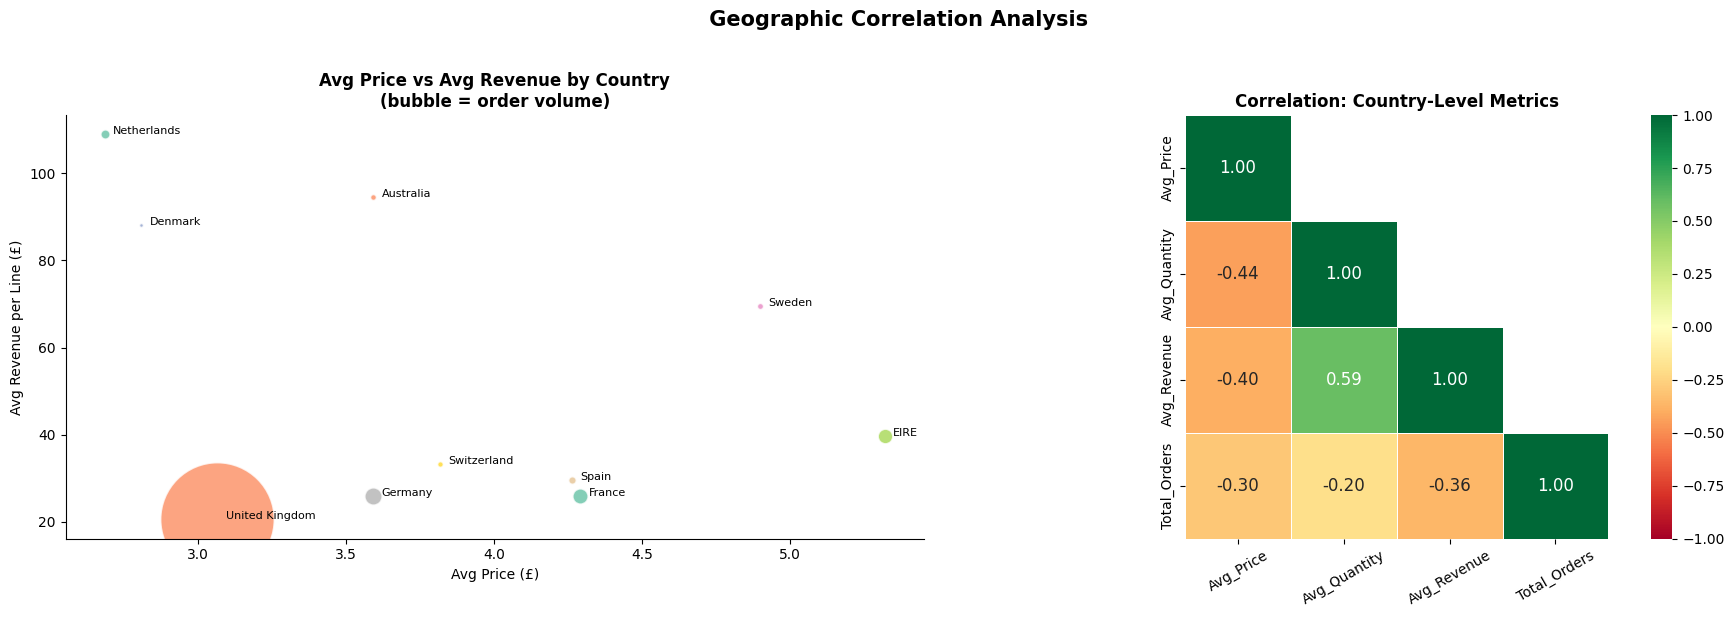

In [9]:
# Revenue vs Frequency by Top Countries

top_countries = (df.groupby('Country')['Revenue']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10)
                   .index.tolist())

country_df = df[df['Country'].isin(top_countries)]

country_stats = country_df.groupby('Country').agg(
    Avg_Price    = ('Price',    'mean'),
    Avg_Quantity = ('Quantity', 'mean'),
    Avg_Revenue  = ('Revenue',  'mean'),
    Total_Orders = ('Invoice',  'nunique'),
).reset_index().sort_values('Avg_Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Avg Price vs Avg Revenue scatter
colors_c = sns.color_palette("Set2", len(country_stats))
for i, (_, row) in enumerate(country_stats.iterrows()):
    axes[0].scatter(row['Avg_Price'], row['Avg_Revenue'],
                    s=row['Total_Orders']/5, color=colors_c[i],
                    alpha=0.8, edgecolors='white', linewidth=1.2)
    axes[0].annotate(row['Country'],
                     (row['Avg_Price'], row['Avg_Revenue']),
                     textcoords="offset points", xytext=(6, 0), fontsize=8)
axes[0].set_title('Avg Price vs Avg Revenue by Country\n(bubble = order volume)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg Price (£)')
axes[0].set_ylabel('Avg Revenue per Line (£)')

# ── Country correlation heatmap
country_corr = country_stats[['Avg_Price','Avg_Quantity',
                               'Avg_Revenue','Total_Orders']].corr()
mask_c = np.triu(np.ones_like(country_corr, dtype=bool), k=1)
sns.heatmap(country_corr, mask=mask_c, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[1], square=True,
            annot_kws={'size': 12})
axes[1].set_title('Correlation: Country-Level Metrics', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(' Geographic Correlation Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

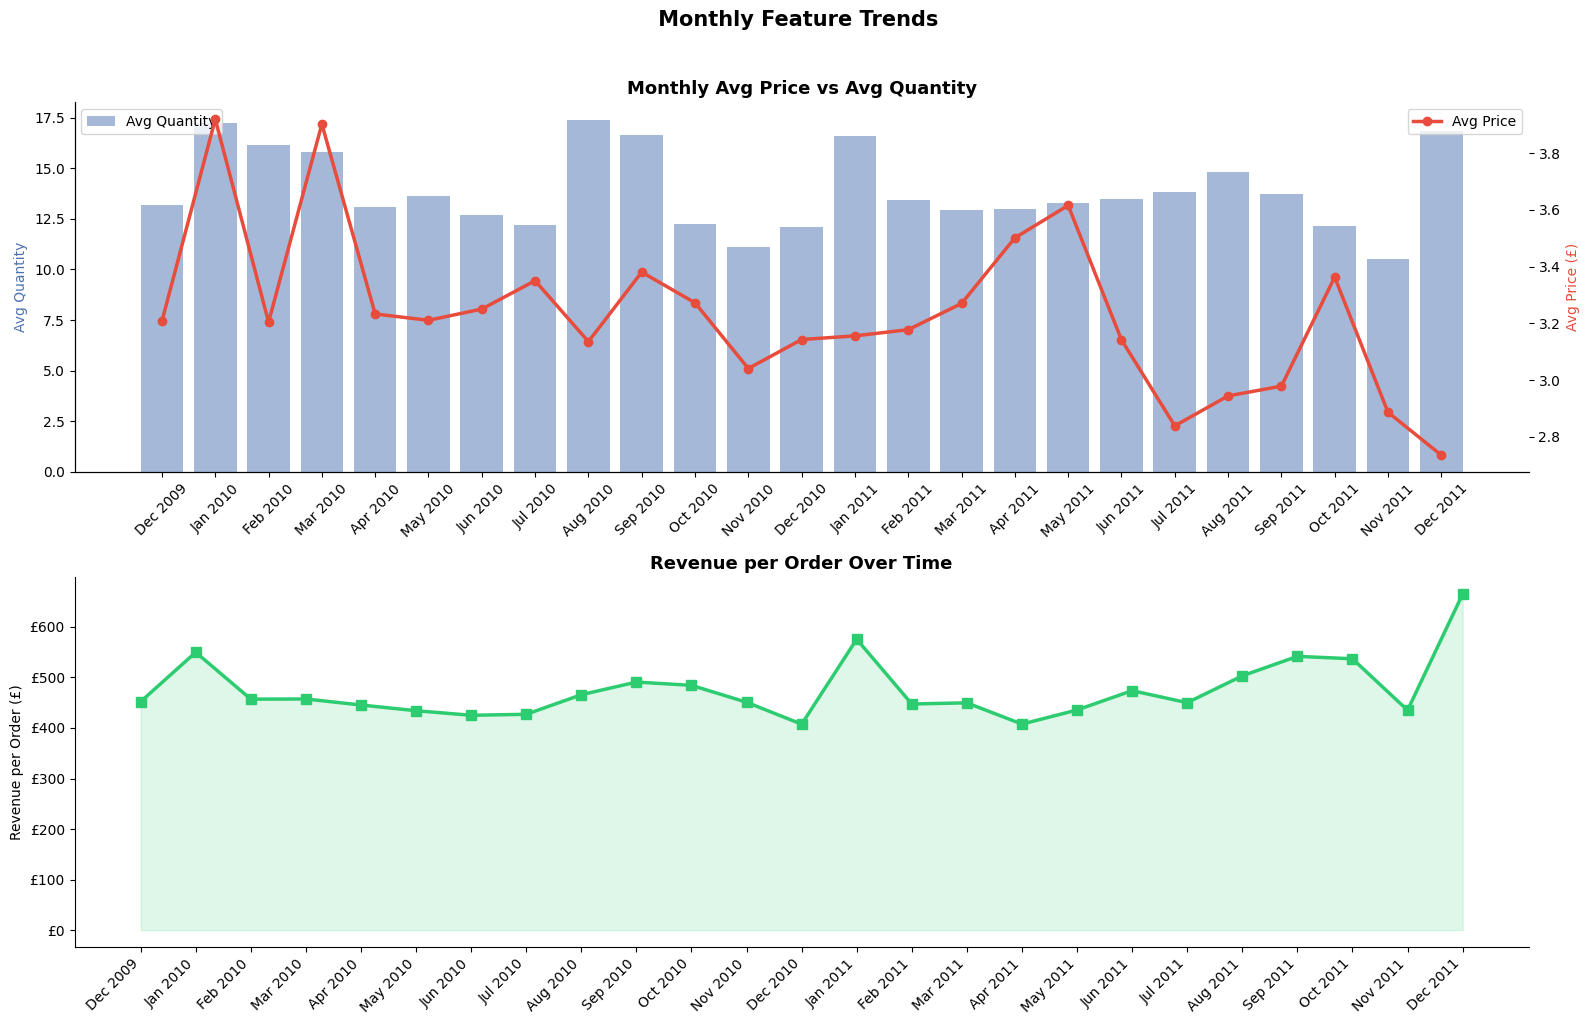

In [10]:
# Monthly Correlation Trend

monthly = df.groupby(['Year','Month']).agg(
    Avg_Price    = ('Price',    'mean'),
    Avg_Quantity = ('Quantity', 'mean'),
    Total_Revenue= ('Revenue',  'sum'),
    Orders       = ('Invoice',  'nunique'),
).reset_index().sort_values(['Year','Month'])

monthly['Label']         = monthly['Month'].apply(
    lambda m: ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec'][m-1]
) + ' ' + monthly['Year'].astype(str)
monthly['Revenue_per_Order'] = monthly['Total_Revenue'] / monthly['Orders']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ── Price & Quantity trend
ax2 = axes[0].twinx()
axes[0].bar(monthly['Label'], monthly['Avg_Quantity'],
            color='#4C72B0', alpha=0.5, label='Avg Quantity')
ax2.plot(monthly['Label'], monthly['Avg_Price'],
         color='#e74c3c', linewidth=2.5, marker='o', label='Avg Price')
axes[0].set_title('Monthly Avg Price vs Avg Quantity', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Quantity', color='#4C72B0')
ax2.set_ylabel('Avg Price (£)', color='#e74c3c')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

# ── Revenue per order trend
axes[1].plot(monthly['Label'], monthly['Revenue_per_Order'],
             color='#2ecc71', linewidth=2.5, marker='s', markersize=7)
axes[1].fill_between(range(len(monthly)), monthly['Revenue_per_Order'],
                     alpha=0.15, color='#2ecc71')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['Label'], rotation=45, ha='right')
axes[1].set_title('Revenue per Order Over Time', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Revenue per Order (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.suptitle(' Monthly Feature Trends', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Final Correlation Summary


print("         CORRELATION ANALYSIS — KEY FINDINGS")


# Top 5 positive
top5_pos = corr_pairs.nlargest(5, 'Pearson_r')
print("\n TOP 5 POSITIVE RELATIONSHIPS:")
for _, row in top5_pos.iterrows():
    strength = 'Very Strong' if row['Pearson_r'] > 0.8 else \
               'Strong'      if row['Pearson_r'] > 0.6 else 'Moderate'
    print(f"  {row['Feature_A']:22} × {row['Feature_B']:22}  r={row['Pearson_r']:+.3f}  [{strength}]")

# Top 5 negative
top5_neg = corr_pairs.nsmallest(5, 'Pearson_r')
print("\n TOP 5 NEGATIVE RELATIONSHIPS:")
for _, row in top5_neg.iterrows():
    strength = 'Very Strong' if row['Pearson_r'] < -0.8 else \
               'Strong'      if row['Pearson_r'] < -0.6 else 'Moderate'
    print(f"  {row['Feature_A']:22} × {row['Feature_B']:22}  r={row['Pearson_r']:+.3f}  [{strength}]")

print(f"  Dataset    : Online Retail II UCI")
print(f"  Rows       : {len(df):,}  (after cleaning)")
print(f"  Customers  : {df['Customer ID'].nunique():,}")
print(f"  Features   : {len(num_cols)} numeric features correlated")
print(f"  Period     : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")


         CORRELATION ANALYSIS — KEY FINDINGS

 TOP 5 POSITIVE RELATIONSHIPS:
  Revenue_Per_Item       × Avg_Price               r=+1.000  [Very Strong]
  Spend_Per_Visit        × Avg_Order_Value         r=+0.936  [Very Strong]
  Avg_Quantity           × Avg_Order_Value         r=+0.928  [Very Strong]
  Spend_Per_Visit        × Avg_Quantity            r=+0.919  [Very Strong]
  Total_Items            × Monetary                r=+0.875  [Very Strong]

 TOP 5 NEGATIVE RELATIONSHIPS:
  Unique_Products        × Recency                 r=-0.325  [Moderate]
  Frequency              × Recency                 r=-0.257  [Moderate]
  Products_Per_Order     × Frequency               r=-0.142  [Moderate]
  Monetary               × Recency                 r=-0.125  [Moderate]
  Total_Items            × Recency                 r=-0.110  [Moderate]
  Dataset    : Online Retail II UCI
  Rows       : 779,425  (after cleaning)
  Customers  : 5,878
  Features   : 11 numeric features correlated
  Period    